## 1. Librerías

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)

## 2. Cargar datos

#### Se importa el archivo directamente desde la carpeta

In [30]:

df_cruceros = pd.read_csv('data/raw/reporte_cruceros_revenue_management.csv')


#### Se utiliza .head() para ver si quedó correctamente carga el dataframe y el separador ultilizado es el correcto.

In [31]:

df_cruceros.head()


,RES_ID,Fecha_Viaje,Fecha_Reserva,Lead_Time_Dias,Noches_Estancia,Barco,Compañia,Tipo_Ruta,Suite_Type,Booking_Source,Package,Guest_Country,Cabinas_Totales_Barco,Cabinas_Reservadas,Porcentaje_Ocupacion_Ciclo,Pasajeros_Reserva,Tripulacion,Ingreso_Total_Reserva_USD,Gasto_Promedio_Diario_Huesped_USD,Puntuacion_Satisfaccion
0,RES-00001,2018-01-05,2017-08-18,140,6,MSC World Europa,MSC Cruceros,Mediterráneo,Balcony,Direct,All Inclusive,usa,2626,1,87.12,2,2138,2762.28,147.39,4.4
1,RES-00002,2018-01-05,2017-09-14,113,6,MSC World Europa,MSC Cruceros,Mediterráneo,Interior,B2B,All Inclusive + EXC,ESPAÑA,2626,1,87.12,1,2138,1863.06,144.91,4.3
2,RES-00003,2018-01-05,2017-11-01,65,6,MSC World Europa,MSC Cruceros,Mediterráneo,Oceanview,Web,All Inclusive,Germany,2626,1,87.12,2,2138,2760.48,147.24,4.6
3,RES-00004,2018-01-05,2017-10-31,66,6,MSC World Europa,MSC Cruceros,Mediterráneo,Interior,Web,All Inclusive + EXC,usa,2626,2,87.12,2,2138,3883.68,158.04,4.3
4,RES-00005,2018-01-05,2017-09-17,110,6,MSC World Europa,MSC Cruceros,Mediterráneo,Oceanview,Direct,All Inclusive + EXC,usa,2626,1,87.12,2,2138,2723.28,144.14,4.3


## 3. Vista general

#### Se utiliza .info() para tener una vista general sobre las columnas, tipo de datos y valores faltantes del dataframe

In [32]:
df_cruceros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77340 entries, 0 to 77339
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RES_ID                             77340 non-null  object 
 1   Fecha_Viaje                        77340 non-null  object 
 2   Fecha_Reserva                      77340 non-null  object 
 3   Lead_Time_Dias                     77340 non-null  int64  
 4   Noches_Estancia                    77340 non-null  int64  
 5   Barco                              77340 non-null  object 
 6   Compañia                           77340 non-null  object 
 7   Tipo_Ruta                          77340 non-null  object 
 8   Suite_Type                         77340 non-null  object 
 9   Booking_Source                     77340 non-null  object 
 10  Package                            77340 non-null  object 
 11  Guest_Country                      75022 non-null  obj

#### Se utiliza un .describe() para ver un pantallazo general de los registros de las columnas

In [33]:

df_cruceros.describe()


,Lead_Time_Dias,Noches_Estancia,Cabinas_Totales_Barco,Cabinas_Reservadas,Porcentaje_Ocupacion_Ciclo,Pasajeros_Reserva,Tripulacion,Ingreso_Total_Reserva_USD,Gasto_Promedio_Diario_Huesped_USD,Puntuacion_Satisfaccion
count,77340.000000,77340.000000,77340.000000,77340.000000,77340.000000,77340.000000,77340.000000,77340.000000,73470.000000,74246.000000
mean,99.062801,7.660732,2082.765581,1.150828,91.176717,1.753039,1648.924295,4132.537654,170.771203,4.583657
std,40.909002,2.904994,626.200954,0.357883,6.413243,0.852200,365.701671,4531.863046,32.648644,0.268357
min,-10.000000,3.000000,1250.000000,1.000000,70.000000,1.000000,1253.000000,947.970000,98.430000,3.700000
25%,71.000000,6.000000,1643.000000,1.000000,86.820000,1.000000,1416.000000,2328.837500,142.500000,4.400000
50%,98.000000,7.000000,2612.000000,1.000000,91.820000,2.000000,1500.000000,3219.300000,168.815000,4.600000
75%,127.000000,9.000000,2732.000000,1.000000,96.390000,2.000000,2138.000000,4819.895000,196.540000,4.800000
max,267.000000,17.000000,2805.000000,2.000000,100.000000,6.000000,2350.000000,304030.800000,271.630000,5.000000


## 4. Transformacion de datos

#### Se analiza si hay valores duplicados a nivel de todas las columas, es decir si la fila entera es duplicada y en caso de que existan se eliminan

In [34]:
n_duplicados = df_cruceros.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 300


In [35]:
if n_duplicados > 0:
    df_cruceros = df_cruceros.drop_duplicates()

#### Tratamiento de valores Nulos

##### Se sustituye el campo vacio de Gastro promedio, por el promedio de todos los registros.

In [36]:

df_cruceros['Gasto_Promedio_Diario_Huesped_USD'] = df_cruceros['Gasto_Promedio_Diario_Huesped_USD'].fillna(df_cruceros['Gasto_Promedio_Diario_Huesped_USD'].median())


##### Se realiza el mismo procedimiento para los registros vacios de Putuacion de Satisfaccion

In [37]:

df_cruceros['Puntuacion_Satisfaccion'] = df_cruceros['Puntuacion_Satisfaccion'].fillna(df_cruceros['Puntuacion_Satisfaccion'].median())


##### Para la columna Guest Country se rellenan los vacios con ubicacion Desconocida

In [38]:

df_cruceros['Guest_Country'] = df_cruceros['Guest_Country'].fillna('UNKNOWN')


##### Se vuelve a comprobar que ya no existan valores Nulos

In [39]:
df_cruceros.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77040 entries, 0 to 77039
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RES_ID                             77040 non-null  object 
 1   Fecha_Viaje                        77040 non-null  object 
 2   Fecha_Reserva                      77040 non-null  object 
 3   Lead_Time_Dias                     77040 non-null  int64  
 4   Noches_Estancia                    77040 non-null  int64  
 5   Barco                              77040 non-null  object 
 6   Compañia                           77040 non-null  object 
 7   Tipo_Ruta                          77040 non-null  object 
 8   Suite_Type                         77040 non-null  object 
 9   Booking_Source                     77040 non-null  object 
 10  Package                            77040 non-null  object 
 11  Guest_Country                      77040 non-null  object 


#### Estandarizacion de Valores

##### Como se pudo ver en las primeras 10 filas del data frame se necesitan estandarizar los valores de la columna Guest Country

In [40]:

df_cruceros['Guest_Country'] = df_cruceros['Guest_Country'].str.strip().str.upper()
df_cruceros['Guest_Country'] = df_cruceros['Guest_Country'].replace({'ESPAÑA': 'SPAIN'})


##### Corregimos valores negativos en el Leadtime

In [41]:

df_cruceros['Lead_Time_Dias'] = df_cruceros['Lead_Time_Dias'].apply(lambda x: x if x >= 0 else np.nan)
df_cruceros['Lead_Time_Dias'] = df_cruceros['Lead_Time_Dias'].fillna(df_cruceros['Lead_Time_Dias'].median())


In [42]:
# Se utiliza un formato mixto porque los datos vienen diferentes.
df_cruceros['Fecha_Viaje'] = pd.to_datetime(df_cruceros['Fecha_Viaje'],format='mixed', errors='coerce')
df_cruceros['Fecha_Reserva'] = pd.to_datetime(df_cruceros['Fecha_Reserva'],format='mixed', errors='coerce')


##### En caso de que haya quedado algun registro vacio por forzar la conversion se elimina la linea

In [43]:
if df_cruceros['Fecha_Viaje'].isna().sum() > 0:
    df_cruceros = df_cruceros.dropna(subset=['Fecha_Viaje'])

if df_cruceros['Fecha_Reserva'].isna().sum() > 0:
    df_cruceros = df_cruceros.dropna(subset=['Fecha_Reserva'])

##### Para la columna de Ingreso total de la reserva en el describe vimos que hay valores maximos que afectan el modelo entonces vamos a estandarizarlos aunque no sabemos si son reales o no, pueden afectar un futuro modelo.

###### Primero definimos con que valor vamos a reemplazar y luego reemplazamos

In [44]:
q25 = df_cruceros['Ingreso_Total_Reserva_USD'].quantile(0.25)
q75 = df_cruceros['Ingreso_Total_Reserva_USD'].quantile(0.75)
iqr = q75 - q25
limite_superior_iqr = q75 + (1.5 * iqr)
percentil_99 = df_cruceros['Ingreso_Total_Reserva_USD'].quantile(0.99)



In [45]:
df_cruceros['Ingreso_Total_Reserva_USD'] = np.where(
    df_cruceros['Ingreso_Total_Reserva_USD'] > percentil_99,
    percentil_99,
    df_cruceros['Ingreso_Total_Reserva_USD']
)

## 5. Exportamos archivo limpio

In [46]:

df_cruceros_final = df_cruceros
os.makedirs('data/processed', exist_ok=True)
df_cruceros_final.to_csv('data/processed/cruceros_procesados.csv', index=False)


## 5. Graficos y primeras muestras del dataset

##### Distribución del Ingreso Total
        Este histograma muestra la concentración de las reservas según el monto total que pagan los clientes lo que nos  permite visualizar rápidamente si la mayoría de los clientes realizan compras de valor bajo, medio o alto.

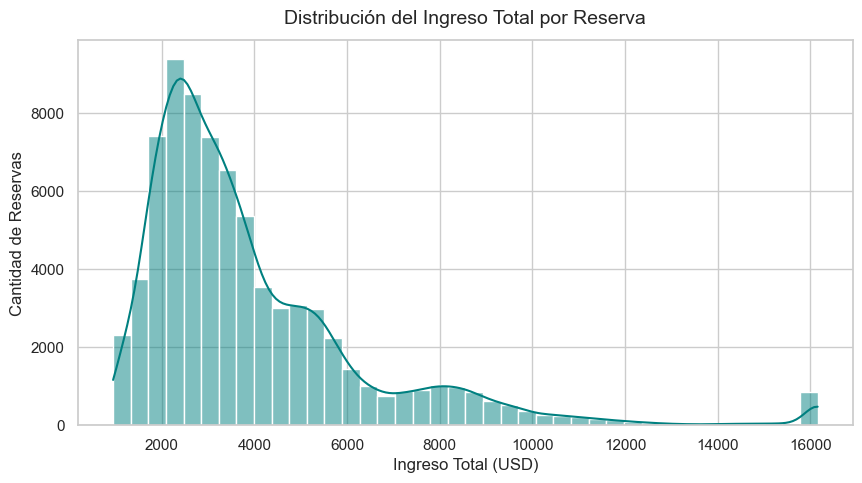

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_cruceros_final['Ingreso_Total_Reserva_USD'], kde=True, color='teal', ax=ax, bins=40)
ax.set_title('Distribución del Ingreso Total por Reserva', fontsize=14, pad=12)
ax.set_xlabel('Ingreso Total (USD)')
ax.set_ylabel('Cantidad de Reservas')
plt.show()

##### Duración de Estancia vs. Ingreso Total
    Este gráfico de dispersión donde cada punto azul representa una reserva la línea roja nos muestra la tendencia estimada.
    Con esto vemos si a mayor cantidad de noches de crucero el ingreso aumenta de forma proporcional.

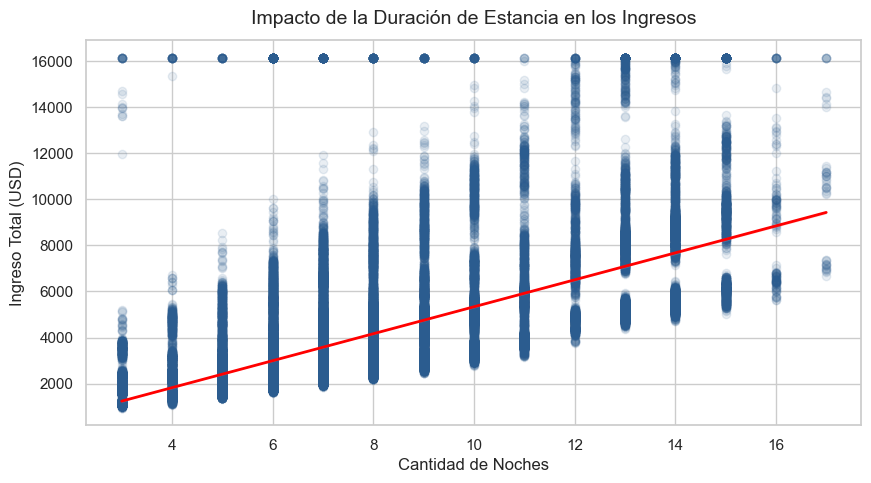

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(
    data=df_cruceros_final, 
    x='Noches_Estancia', 
    y='Ingreso_Total_Reserva_USD',
    scatter_kws={'alpha': 0.1, 'color': '#2b5c8f'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=ax
)
ax.set_title('Impacto de la Duración de Estancia en los Ingresos', fontsize=14, pad=12)
ax.set_xlabel('Cantidad de Noches')
ax.set_ylabel('Ingreso Total (USD)')
plt.show()

##### Ingreso según Tipo de Habitación
    Este diagrama compara el comportamiento del gasto según el tipo de suite la línea representa el valor promedio de ese grupo, nos permite identificar cuáles categorías de habitación aportan mayor margen.

C:\Users\nicolas.perez\AppData\Local\Temp\ipykernel_19780\2920954242.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


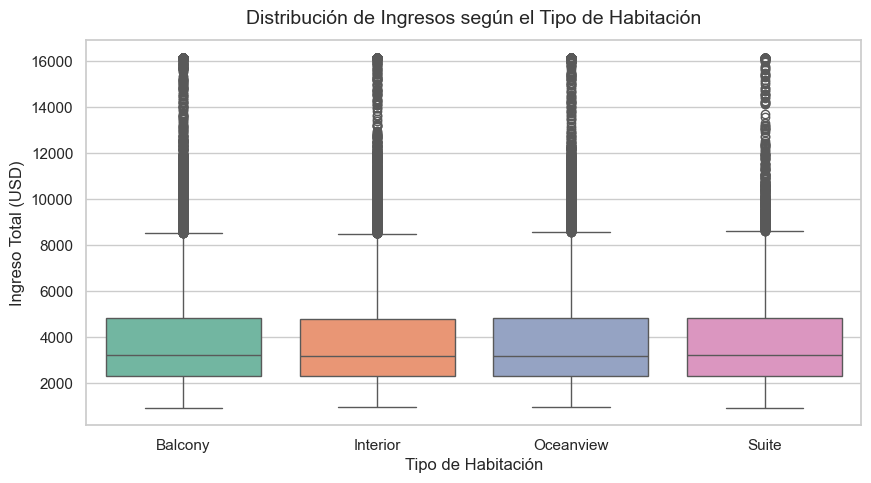

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df_cruceros_final, 
    x='Suite_Type', 
    y='Ingreso_Total_Reserva_USD', 
    palette='Set2', 
    ax=ax
)
ax.set_title('Distribución de Ingresos según el Tipo de Habitación', fontsize=14, pad=12)
ax.set_xlabel('Tipo de Habitación')
ax.set_ylabel('Ingreso Total (USD)')
plt.show()

##### Matriz de Correlaciones

    Este mapa de calor nos muestra los coeficientes de relación entre todas las variables numéricas del dataset. Cuanto más cercano a 1 o -1 sea el número, más fuerte es la relación entre dos datos.
    Nos ayuda a descubrir que variables del negocio (pasajeros, noches, ocupación) influyen en los ingresos y cuáles no aportan información relevante.

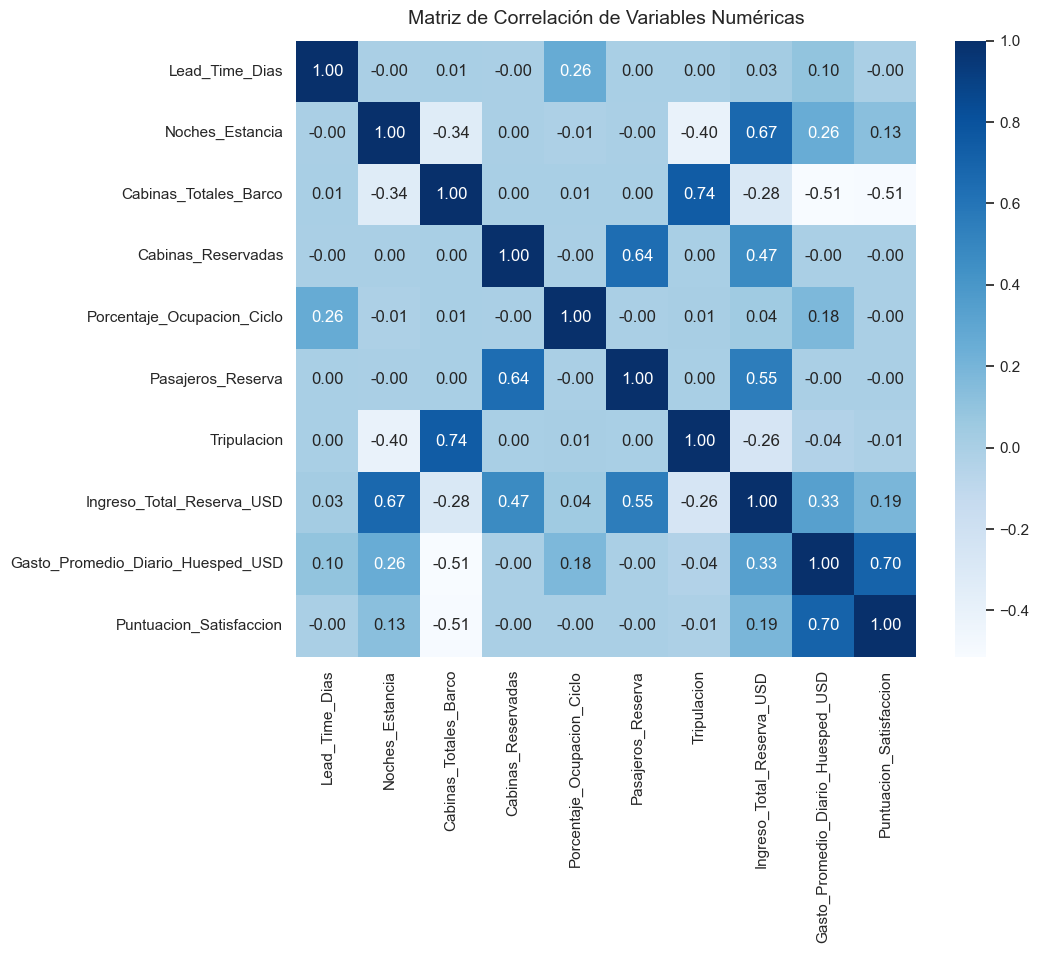

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = df_cruceros_final.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues', ax=ax, cbar=True)
ax.set_title('Matriz de Correlación de Variables Numéricas', fontsize=14, pad=12)
plt.show()

##### Evolución de Ingresos por Fecha de Viaje

    Línea de tiempo que agrupa la facturación total generada mes a mes a lo largo del periodo analizado.
    Con esto identificamos la estacionalidad del negocio, mostrando con claridad cuáles son los meses de temporada alta y temporada baja para la toma de decisiones comerciales.

C:\Users\nicolas.perez\AppData\Local\Temp\ipykernel_19780\2519998545.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_temporal = df_cruceros_final.set_index('Fecha_Viaje').resample('M')['Ingreso_Total_Reserva_USD'].sum().reset_index()


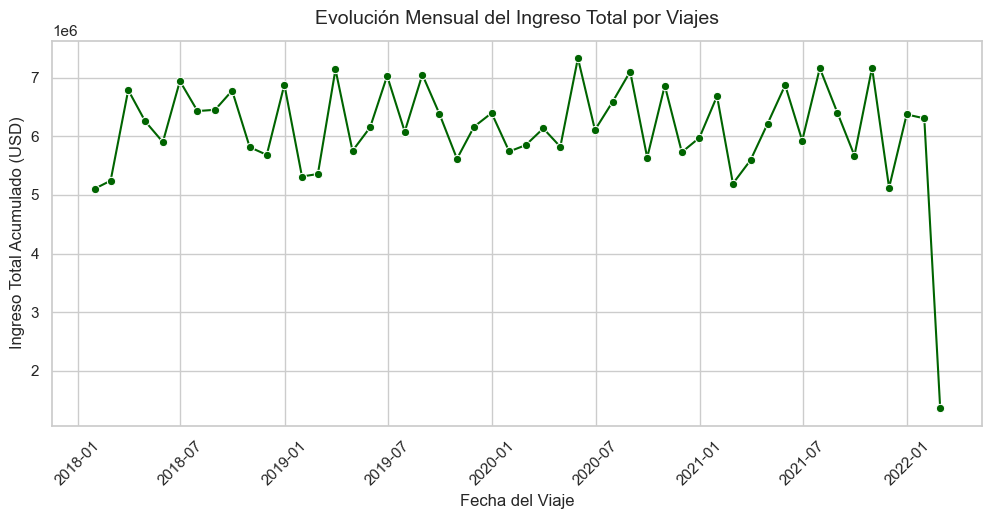

In [51]:
df_temporal = df_cruceros_final.set_index('Fecha_Viaje').resample('M')['Ingreso_Total_Reserva_USD'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=df_temporal, x='Fecha_Viaje', y='Ingreso_Total_Reserva_USD', color='darkgreen', marker='o', ax=ax)
ax.set_title('Evolución Mensual del Ingreso Total por Viajes', fontsize=14, pad=12)
ax.set_xlabel('Fecha del Viaje')
ax.set_ylabel('Ingreso Total Acumulado (USD)')
plt.xticks(rotation=45)
plt.show()

##### Rentabilidad por Canal de Venta y Paquete Comercial

    Este gráfico de barras agrupadas que compara cuánto dinero ingresa a través de cada canal de reserva (Web, Directo, Agencia B2B) segregado por tipo de paquete adquirido. Sirve para deetectar las combinaciones comerciales más exitosas.

C:\Users\nicolas.perez\AppData\Local\Temp\ipykernel_19780\2149450320.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


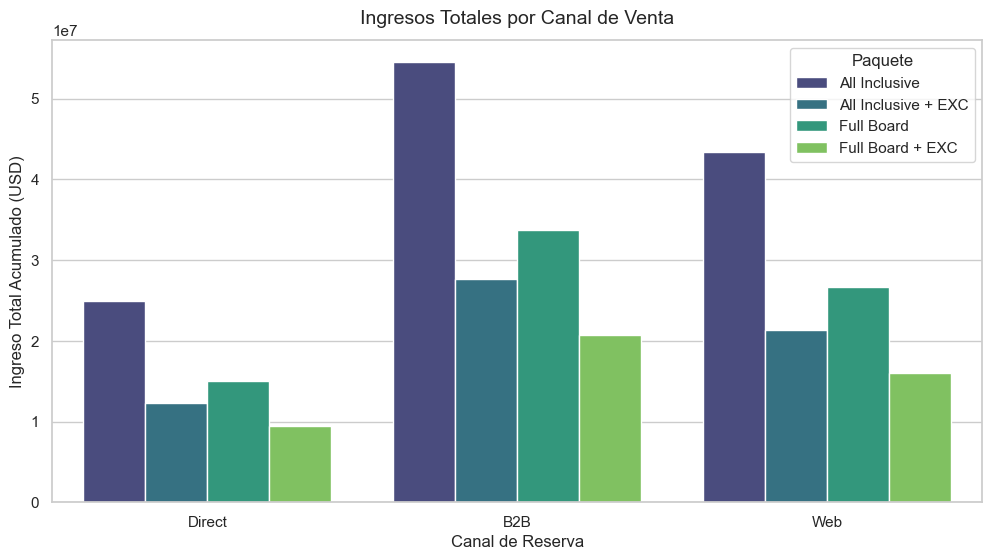

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=df_cruceros_final, 
    x='Booking_Source', 
    y='Ingreso_Total_Reserva_USD', 
    hue='Package', 
    estimator=sum, 
    ci=None, 
    palette='viridis', 
    ax=ax
)
ax.set_title('Ingresos Totales por Canal de Venta', fontsize=14, pad=12)
ax.set_xlabel('Canal de Reserva')
ax.set_ylabel('Ingreso Total Acumulado (USD)')
plt.legend(title='Paquete')
plt.show()

##### Nivel de Ocupación del Barco vs Satisfacción del Cliente

    Este grafico relaciona el porcentaje de llenado del barco durante el viaje con la puntuación de satisfacción otorgada por los huéspedes.
    Con esto se evalúa si viajar en barcos a máxima capacidad afecta negativamente la experiencia percibida por el cliente o si la calidad del servicio se mantiene estable.    

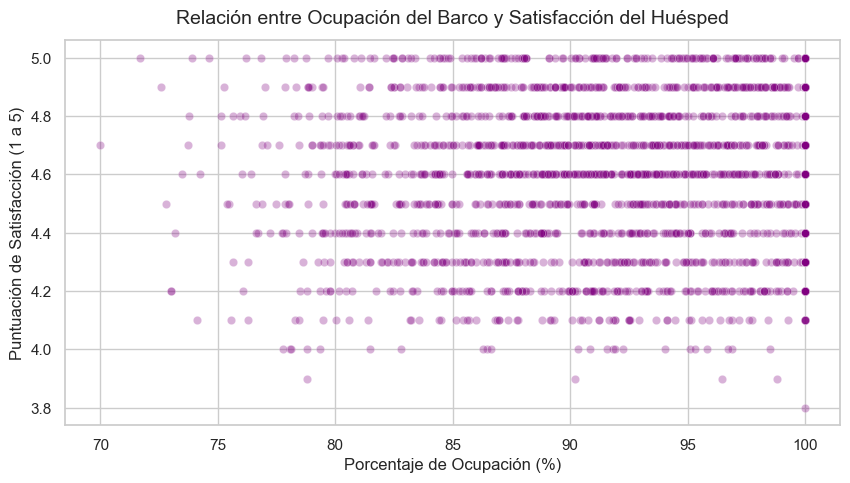

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=df_cruceros_final.sample(min(2000, len(df_cruceros_final))), 
    x='Porcentaje_Ocupacion_Ciclo', 
    y='Puntuacion_Satisfaccion', 
    alpha=0.3, 
    color='purple', 
    ax=ax
)
ax.set_title('Relación entre Ocupación del Barco y Satisfacción del Huésped', fontsize=14, pad=12)
ax.set_xlabel('Porcentaje de Ocupación (%)')
ax.set_ylabel('Puntuación de Satisfacción (1 a 5)')
plt.show()